In [1]:
import time
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState
from tqdm import tqdm

from flightning import FLIGHTNING_PATH
from flightning.algos import bptt
from flightning.envs import HoveringFeaturesEnv, rollout
from flightning.modules import MLP
from flightning.utils.math import normalize

# Train a Vision-based Policy Using BPTT

Here, we show how to use pretraining and backpropagtion through time (BPTT) to train a quadrotor control policy that only observes visual features as pixel coordinates.

## Define the Training Environment and Policy

In [2]:
# seed
key = jax.random.key(0)
# define the environment
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringFeaturesEnv(
    max_steps_in_episode=3 * int(1 / 0.02),
    dt=0.02,
    delay=0.05,
    velocity_std=2.,
    yaw_scale=1.0,
    pitch_roll_scale=0.3,
    omega_std=2.,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
    num_last_quad_states=5,
    skip_frames=1,
)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]


# define policy
policy_net = MLP(
    [obs_dim, 1024, 1024, action_dim],
    initial_scale=1.0,
    action_bias=env.hovering_action,
)
key, key_ = jax.random.split(key)
policy_params = policy_net.initialize(key_)

# create fake trainstate
tx_idle = optax.adam(0)
train_state_collection = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx_idle
)

## Pretraining

### Define Policy and Rollout Function

In [3]:
def collect_data(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(
        partial(rollout, real_step=True, num_steps=1000),
        in_axes=(None, 0, None),
    )
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy_collection(obs, key):
    return train_state_collection.apply_fn(train_state_collection.params, obs)

### Collect Data

In [4]:
time_rollout = time.time()
transitions = collect_data(env, policy_collection, 100, jax.random.key(3))
time_rollout = time.time() - time_rollout
print(f"Rollout time: {time_rollout}")

Rollout time: 8.148198366165161


### Create the Dataset

In [5]:
# inputs: observations
observations = transitions.obs
observations = jnp.reshape(observations, (-1, observations.shape[-1]))

# targets: quadrotor state
p = transitions.state.quadrotor_state.p
# normalize the position
p = normalize(p, env.world_box.min, env.world_box.max)
R = transitions.state.quadrotor_state.R
v = transitions.state.quadrotor_state.v
v = normalize(v, env.v_min, env.v_max)
# flatten the last axis of R
R = jnp.reshape(R, (*R.shape[:-2], -1))
# concatenate the states
targets = jnp.concatenate([p, R, v], axis=-1)
targets = jnp.reshape(targets, (-1, targets.shape[-1]))

### Define the Pretraining Pipeline

In [6]:
@jax.jit
def train_step(state, obs, targets):
    def loss_fn(params):
        preds = state.apply_fn(params, obs)
        loss = jnp.mean(jnp.abs(preds - targets))
        return loss

    grads = jax.grad(loss_fn)(state.params)  # Compute gradients
    new_state = state.apply_gradients(grads=grads)  # Update parameters
    return new_state


# Training loop
def train_loop(state, observations, targets, epochs=100, batch_size=32):
    dataset_size = observations.shape[0]
    for epoch in tqdm(range(epochs)):
        # Shuffle the data at the start of each epoch
        perm = jax.random.permutation(jax.random.PRNGKey(epoch), dataset_size)
        obs_shuffled = observations[perm]
        targets_shuffled = targets[perm]

        # Iterate over the dataset in batches
        for i in range(0, dataset_size, batch_size):
            batch_obs = obs_shuffled[i : i + batch_size]
            batch_targets = targets_shuffled[i : i + batch_size]

            # Perform a training step
            state = train_step(state, batch_obs, batch_targets)

    return state

### Create Predictor MLP 

In [7]:
predictor = MLP([obs_dim, 1024, 1024, targets.shape[-1]], initial_scale=.1)
predictor_params = predictor.initialize(jax.random.PRNGKey(0))

tx_predictor = optax.adam(1e-3)
train_state_predictor = TrainState.create(
    apply_fn=predictor.apply, params=predictor_params, tx=tx_predictor
)
epochs = 500
batch_size = 1024

train_state_predictor_new = train_loop(train_state_predictor, observations,
                                       targets,
                                       epochs, batch_size)

100%|██████████| 500/500 [00:17<00:00, 29.26it/s]


### Copy Parameters to Policy

In [8]:
policy_params['params']['Dense_0'] = train_state_predictor_new.params['params']['Dense_0']
policy_params['params']['Dense_1'] = train_state_predictor_new.params['params']['Dense_1']

## Create Policy Optimization Envirionment

In [9]:
env = HoveringFeaturesEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    delay=0.05,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
    num_last_quad_states=5,
    skip_frames=1,
)

# create trainstate
scheduler = optax.cosine_decay_schedule(1e-3, 1000)
tx = optax.adam(scheduler)
train_state = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx
)

## Train the Policy Using BPTT

In [10]:
time_start = time.time()
res_dict = bptt.train(
    env,
    train_state,
    num_epochs=500,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=1000,
    key=jax.random.key(0),
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

Episode: 0, Loss: 23.04
Episode: 0, Grad max: 1.4229
Episode: 10, Loss: 18.80
Episode: 10, Grad max: 0.2672
Episode: 20, Loss: 15.38
Episode: 20, Grad max: 0.6159
Episode: 30, Loss: 13.61
Episode: 30, Grad max: 1.8593
Episode: 40, Loss: 11.54
Episode: 40, Grad max: 0.9922
Episode: 50, Loss: 10.10
Episode: 50, Grad max: 1.3360
Episode: 60, Loss: 9.71
Episode: 60, Grad max: 2.1614
Episode: 70, Loss: 8.83
Episode: 70, Grad max: 2.5880
Episode: 80, Loss: 8.28
Episode: 80, Grad max: 1.2873
Episode: 90, Loss: 7.90
Episode: 90, Grad max: 1.3120
Episode: 100, Loss: 7.86
Episode: 100, Grad max: 1.4640
Episode: 110, Loss: 7.69
Episode: 110, Grad max: 3.0224
Episode: 120, Loss: 7.39
Episode: 120, Grad max: 1.9432
Episode: 130, Loss: 7.58
Episode: 130, Grad max: 3.9109
Episode: 140, Loss: 7.50
Episode: 140, Grad max: 2.0060
Episode: 150, Loss: 7.47
Episode: 150, Grad max: 2.5619
Episode: 160, Loss: 7.36
Episode: 160, Grad max: 1.4654
Episode: 170, Loss: 7.22
Episode: 170, Grad max: 1.7892
Episode:

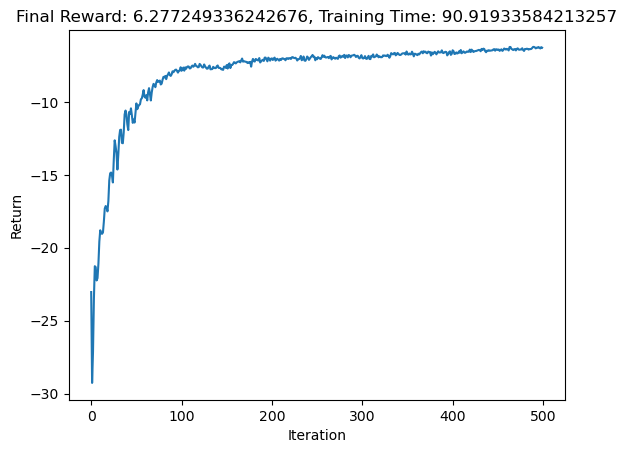

In [11]:
losses = res_dict["metrics"]
plt.plot(-losses)
plt.title(f"Final Reward: {losses[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [12]:
new_train_state = res_dict["runner_state"].train_state

def get_rollouts(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None))
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions

def policy_trained(obs, key):
    return train_state.apply_fn(new_train_state.params, obs)

env_eval = HoveringFeaturesEnv(
    max_steps_in_episode=10 * int(1 / dt),
    dt=dt,
    delay=0.05,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    num_last_quad_states=5,
    skip_frames=1,
)
transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))

/home/nat-nus/apg/rpg_flightning/flightning/envs/hovering_state_env.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


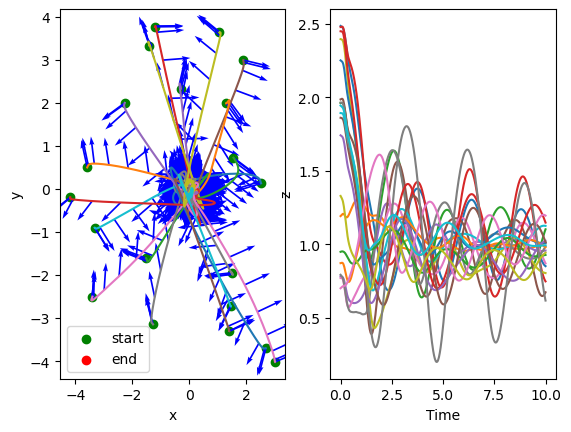

In [13]:
env_eval.plot_trajectories(transitions_eval)